In [1]:
import torch
from torch.nn.functional import threshold

from models import ou_model, logistic_model, simulate, plot_traj_set

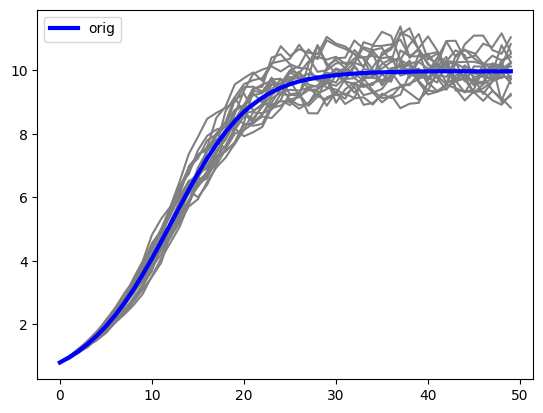

In [28]:
# logistic growth  process
# X_{t+1} = X_t + r * X_t * (1 - X_t/k)  + X_t *sqrt(k)*sigma*ep;  eps~normal(0,1)

time_steps = 50
#fast convergence to x=2, with little noise
params = {'time': time_steps,      # time steps
            'init_x':1.0,  # initial x
            'r': 0.18,        #
            'k': 10.0,       #
            'sigma': 0.1}

#slower convergence to x=2, higher variance
params2 = {'time': time_steps,      # time steps
            'init_x':0.8,  # initial x
            'r': 0.22,        #
            'k': 10.0,        #
            'sigma': 0.18}



trajs = simulate(logistic_model, 10000, params2)

plot_traj_set(trajs, single_traj=20, color='blue', label='orig')

In [29]:
t = 40

pre = torch.prod(trajs[:,:t]<10.0, dim=1)
post = trajs[:,t] >= 10.0
reach = pre * post
reach.float().mean()


tensor(0.0138, dtype=torch.float32)

In [30]:
thr = 10.5
reach = torch.max(trajs, dim=1).values  > thr
p_ev = reach.float().mean()
print("eventually reach",p_ev)




eventually reach tensor(0.7366, dtype=torch.float32)


In [31]:
# sometimes[0,b] historically |x - 10|  <= 1
threshold = 10
reach_int  = 1.0
#aromic proposition
atom = (torch.abs(trajs - threshold) <= reach_int).int()

# historically [t,T] atom same as globally atom
historically = torch.flip(torch.cumprod(torch.flip(atom, dims=[1]), dim=1), dims=[1])
#eventually[0,b]  globally atom
sometimes = torch.cummax(historically, dim=1).values

truth_probability = sometimes.float().mean(dim=0)
#b = 30
truth_probability[49]

tensor(0.9451, dtype=torch.float32)

DeGAS section

In [32]:
# import module optimization to use DeGAS
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

In [33]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('logistic.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,currX=0.8,smoothed:currX=0.8+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state1': StateNode<state1,True,X[i]=currX,smoothed:X[i]=currX+ gm([1.], [0.], [0.0010000000])>,
 'state2': StateNode<state2,None,xSquare=currX*currX>,
 'state3': StateNode<state3,None,noise=gm([1.0],[0.000000],[0.032400])>,
 'state4': StateNode<state4,None,xNoise=currX*noise>,
 'state5': StateNode<state5,None,newX=1.22*currX-0.022*xSquare+xNoise,smoothed:newX=1.22*currX-0.022*xSquare+xNoise+ gm([1.], [0.], [0.0010000000])>,
 'state6': StateNode<state6,None,currX=newX,smoothed:currX=newX+ gm([1.], [0.], [0.0010000000])>,
 'state7': StateNode<state7,False,skip>,
 'exit': ExitNode<>}

In [34]:
#run SOGA
output_dist = start_SOGA(cfg)

In [35]:
output_dist

Dist<['X[0]', 'X[1]', 'X[2]', 'X[3]', 'X[4]', 'X[5]', 'X[6]', 'X[7]', 'X[8]', 'X[9]', 'X[10]', 'X[11]', 'X[12]', 'X[13]', 'X[14]', 'X[15]', 'X[16]', 'X[17]', 'X[18]', 'X[19]', 'X[20]', 'X[21]', 'X[22]', 'X[23]', 'X[24]', 'X[25]', 'X[26]', 'X[27]', 'X[28]', 'X[29]', 'X[30]', 'X[31]', 'X[32]', 'X[33]', 'X[34]', 'X[35]', 'X[36]', 'X[37]', 'X[38]', 'X[39]', 'X[40]', 'X[41]', 'X[42]', 'X[43]', 'X[44]', 'X[45]', 'X[46]', 'X[47]', 'X[48]', 'X[49]', 'currX', 'xSquare', 'noise', 'xNoise', 'newX'],pi: tensor([[1.]])
mu: tensor([[ 0.8000,  0.9619,  1.1532,  1.3776,  1.6388,  1.9401,  2.2838,  2.6711,
          3.1011,  3.5708,  4.0744,  4.6037,  5.1479,  5.6944,  6.2303,  6.7429,
          7.2215,  7.6580,  8.0473,  8.3876,  8.6795,  8.9260,  9.1312,  9.2999,
          9.4374,  9.5484,  9.6374,  9.7084,  9.7649,  9.8095,  9.8447,  9.8725,
          9.8943,  9.9114,  9.9248,  9.9353,  9.9436,  9.9500,  9.9550,  9.9590,
          9.9621,  9.9645,  9.9663,  9.9678,  9.9690,  9.9699,  9.9706,  9.9711

In [47]:
mu = output_dist.gm.mu[0,:time_steps]
sigma = output_dist.gm.sigma[0,:time_steps,:time_steps]

In [48]:
# computing the prob of being below 10 in the first 40 time instants and above then in the last 10 time instants.
A = torch.clone(mu)
B = torch.clone(mu)
A[:40] = -torch.inf
B[:40] = 10.0
A[40:] = 10.0
B[40:] = torch.inf

print(sigma.shape)
print(mu.shape)

torch.Size([50, 50])
torch.Size([50])


In [49]:
p = ghk_mvnorm_prob(mu, sigma, A, B, n_samples=50000)
print(p)

tensor(0.0016)


In [50]:
#calcolo la reachability di X>10 esattamente  al tempo 40.
#la costante di normalizzazione. devo essere sotto 10 fino al tempo 39, marginalizzo sul tempo 40.
t = 40
A[:t+1] = -torch.inf
B[:t] = 10.0
B[t] = torch.inf
c = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
print("normalization constant",c.item())
A[t] = 10.0
B[t] = torch.inf
pj = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
print("joint reach",pj.item())
p = pj/c
print("reach prob",p.item())

normalization constant 0.08524246329304525
joint reach 0.013104730061493732
reach prob 0.15373476498963304


In [51]:
time = 50
thr = 10.5
A = torch.clone(mu)
B = torch.clone(mu)
pt = torch.clone(mu)
for t in range(time):
    A[:t] = -torch.inf
    B[:t] = thr
    A[t] = thr
    B[t] = torch.inf
    pt[t] = ghk_mvnorm_prob(mu[:t+1], sigma[:t+1,:t+1], A[:t+1], B[:t+1], n_samples=50000)
p = pt.sum(dim=0)
print(pt)
print(p)




tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.8709e-16, 2.5687e-11,
        1.1588e-07, 1.3681e-05, 1.4819e-04, 9.9679e-04, 3.1459e-03, 7.3918e-03,
        1.3679e-02, 2.0497e-02, 2.6525e-02, 3.1905e-02, 3.4993e-02, 3.7217e-02,
        3.8328e-02, 3.8236e-02, 3.8124e-02, 3.6872e-02, 3.5596e-02, 3.4182e-02,
        3.2793e-02, 3.1191e-02, 2.9365e-02, 2.7855e-02, 2.6428e-02, 2.5161e-02,
        2.3653e-02, 2.2647e-02, 2.1117e-02, 1.9528e-02, 1.8761e-02, 1.8090e-02,
        1.6908e-02, 1.5859e-02])
tensor(0.7272)


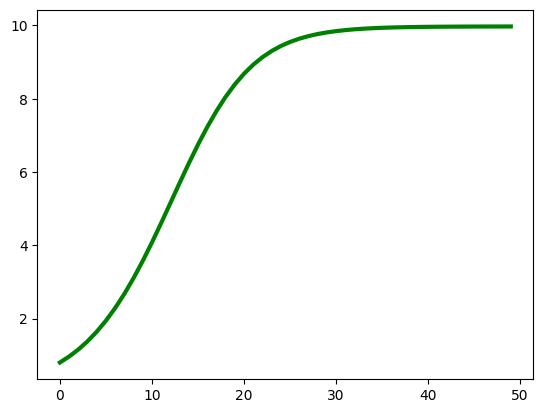

In [52]:
T = 50
#output_dist
plt.plot(range(T), output_dist.gm.mean()[:T].detach(), lw=3, color='green', label='SOGA mean')

In [54]:
mu = torch.tensor([0.0, 0.0], dtype=torch.float64)
sigma = torch.tensor([[1.0, 0.0],
                      [0.0, 1.0]], dtype=torch.float64)
A = torch.tensor([0.0, -torch.inf], dtype=torch.float64)
B = torch.tensor([torch.inf, 0.0], dtype=torch.float64)

p = ghk_mvnorm_prob(mu, sigma, A, B, n_samples=50000)
print(p)

tensor(0.2500)
